SST-Taux feedback :

Computes zonal wind stress anomalies (TauxA) in the western equatorial Pacific (horizontal Niño4 average) regressed onto sea surface temperature anomalies (SSTA) in the eastern equatorial Pacific (horizontal Niño3 average).

Reference observations:
TropFlux 1979-2018 (main)

SST: ERSSTv5 1854-2023, HadISST 1870-2023, COBE2 1850-2023, ERA5 1940-2022, 20CRv3 1836-2015, NCEP2 1979-2023

Taux: ERA5 1940-2022, 20CRv3 1836-2015, NCEP2 1979-2023

In [1]:
from dask.distributed import Client, progress
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44133,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46461,Total threads: 4
Dashboard: /proxy/41571/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:34063,


In [2]:
from esmvalcore.dataset import Dataset

from esmvalcore.config import CFG

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config_object.py:663: ESMValCoreDeprecationWarning: Usage of the single configuration file ~/.esmvaltool/config-user.yml or specifying it via CLI argument `--config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. To switch to the new configuration system, (1) run `mkdir -p ~/.config/esmvaltool && mv /home/548/cxc548/.esmvaltool/config-user.yml ~/.config/esmvaltool` (or alternatively use a custom `--config_dir`) and omit `--config_file`, or (2) use the environment variable ESMVALTOOL_CONFIG_DIR to specify a custom user configuration directory. New configuration files present at ~/.config/esmvaltool or specified via `--config_dir` are currently ignored.
  config_obj.reload()
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:452: ESMValCoreDeprecationWarning:

In [3]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
#esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
dpi=300
esm_file_ts = "/scratch/p66/fc6164/SeptSpinupA/ts_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-088912.nc"
esm_file_tauu = "/scratch/p66/fc6164/SeptSpinupA/tauu_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-089012.nc"

mylabel = "SeptSpinUpA"
startyear=610
endyear=790
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/scratch/{os.environ['PROJECT']}/{os.environ['USER']}/nesp/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM ts path: ",esm_file_ts)
print("ESM tauu path: ",esm_file_tauu)

print("Plot folder path: ",plotfolder)

ESM ts path:  /scratch/p66/fc6164/SeptSpinupA/ts_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-088912.nc
ESM tauu path:  /scratch/p66/fc6164/SeptSpinupA/tauu_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-089012.nc
Plot folder path:  /scratch/eg3/cxc548/nesp/


In [4]:
model_ctrlts_datasets = { 
"ACCESS-ESM1-5": 
    Dataset(
    short_name='ts',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="0900101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
)}

#tauu
model_ctrltauu_datasets = { 
"ACCESS-ESM1-5": 
    Dataset(
    short_name='tauu',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="0900101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
)}

obs_tos_datasets = {
"HadISST": 
    Dataset(
    short_name='tos',
    dataset='HadISST',
    mip="Omon",
    project='OBS',
    type='reanaly',
    timerange="19790101/20181231",
    tier=2),
# "TROPFLUX":
#     Dataset(
#     short_name='tos',
#     dataset='TROPFLUX',
#     mip="Omon",
#     project='OBS6',
#     type='reanaly',
#     tier=2),
"ERSSTv5":
    Dataset(
    short_name='tos',
    dataset='NOAA-ERSSTv5',
    mip="Omon",
    project='OBS6',
    type='reanaly',
    tier=2),
}
obs_tauu_datasets = {
"NOAA-CIRES-20CR-V2": 
    Dataset(
    short_name='tauu',
    dataset='NOAA-CIRES-20CR-V2',
    mip="Amon",
    project='OBS6',
    type='reanaly',
    timerange="187101/201212",
    tier=2),
}

In [5]:
for name, dataset in model_ctrlts_datasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")
# for name, dataset in model_ctrltauu_datasets.items():
#     dataset.add_supplementary(short_name='sftlf', mip="fx")
#     dataset.add_supplementary(short_name="areacella", mip="fx")


In [6]:
import iris
from iris.util import equalise_attributes


model_ctrlts_datasets = {name: dataset.load() for name, dataset in model_ctrlts_datasets.items()}
model_ctrltauu_datasets = {name: dataset.load() for name, dataset in model_ctrltauu_datasets.items()}

obs_tos_datasets = {name: dataset.load() for name, dataset in obs_tos_datasets.items()}
obs_tauu_datasets = {name: dataset.load() for name, dataset in obs_tauu_datasets.items()}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:452: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config.py:59: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Please use the configuration option `extra_facets` instead (see https://github.com/ESMValGroup/ESMValCore/pull/2747 for details). To silent this warning and ignore deprecated extra facets, set the environment variable ESMVALTOOL_USE_NEW_EXTRA_FACETS_CON

In [7]:
import iris
from iris.util import equalise_attributes

esm16cube_ts = iris.load_cube(esm_file_ts,'surface_temperature')

print(esm_file_tauu)
esm16cube_tauu = iris.load_cube(esm_file_tauu,'surface_downward_eastward_stress')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/cf.py:664: IrisCfMissingVarWarning: Missing CF-netCDF grid mapping variable 'latitude_longitude', referenced by netCDF variable 'ts'
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/cf.py:880: IrisCfMissingVarWarning: Missing CF-netCDF measure variable 'areacella', referenced by netCDF variable 'ts'
  warnings.warn(


/scratch/p66/fc6164/SeptSpinupA/tauu_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-089012.nc


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/cf.py:664: IrisCfMissingVarWarning: Missing CF-netCDF grid mapping variable 'latitude_longitude', referenced by netCDF variable 'tauu'
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/cf.py:880: IrisCfMissingVarWarning: Missing CF-netCDF measure variable 'areacella', referenced by netCDF variable 'tauu'
  warnings.warn(


In [8]:
from esmvalcore.preprocessor import anomalies
from esmvalcore.preprocessor import area_statistics
from esmvalcore.preprocessor import seasonal_statistics
from esmvalcore.preprocessor import rolling_window_statistics
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import extract_season
from esmvalcore.preprocessor import extract_month
from esmvalcore.preprocessor import detrend
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import detrend
from esmvalcore.preprocessor import mask_landsea
from esmvalcore.preprocessor import extract_time
import iris

import matplotlib.pyplot as plt
import iris.quickplot as qplt
import numpy as np

In [9]:
def sst_east(cube, start, end):
    nino3_region = {"start_longitude": 210., "end_longitude": 270., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=start, end_year=end, start_month=1, end_month=12, start_day=1, end_day=31)
    cube = convert_units(cube, units="degC")
#    cube = mask_landsea(cube, mask_out="land") #not req
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = anomalies(cube, period="monthly")
    cube = detrend(cube, dimension="time", method="linear")
    cube = extract_region(cube, **nino3_region)
    # cube = regrid(cube, target_grid="1x1", scheme="linear")  #not req
    cube = area_statistics(cube,operator='mean')
    
    return cube


def taux_west(cube, start, end):
    region = {"start_longitude": 160., "end_longitude": 210., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=start, end_year=end, start_month=1, end_month=12, start_day=1, end_day=31)
    cube = convert_units(cube, units="1e-3 N/m2")

#    cube = mask_landsea(cube, mask_out="land") #not req?
#    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = anomalies(cube, period="monthly")
    cube = detrend(cube, dimension="time", method="linear")
    cube = extract_region(cube, **region)
    cube = area_statistics(cube,operator='mean')
    return cube   




In [10]:
model_ctrltos_prep = {name: sst_east(dataset,900,1100) for name, dataset in model_ctrlts_datasets.items()}
#for name,dataset in model_ctrltauu_datasets.items():
#    model_ctrltauu_datasets_swap = dataset.transpose([2,1,0])
print(model_ctrltauu_datasets['ACCESS-ESM1-5'].shape)
model_ctrltauu_prep = {name: taux_west(dataset,900,1100) for name, dataset in model_ctrltauu_datasets.items()}

(2397, 145, 192)


In [11]:
model_tos_prep = sst_east(esm16cube_ts,startyear,endyear)
model_tauu_prep = taux_west(esm16cube_tauu,startyear,endyear)

In [12]:
obs_tos_prep = {name: sst_east(dataset,1979,2012) for name, dataset in obs_tos_datasets.items()}
obs_tauu_prep = {name: taux_west(dataset,1979,2012) for name, dataset in obs_tauu_datasets.items()}

In [13]:

def linreg_1d(tauu_cube, ts_cube):
    B_data = ts_cube.data
    B_with_intercept = np.vstack([B_data, np.ones_like(B_data)]).T
    coefs, _, _, _ = np.linalg.lstsq(B_with_intercept, tauu_cube.data, rcond=None)
    slope, intercept = coefs[0], coefs[1]
    return slope, intercept

In [14]:
# import dask.array as da


# print(obs_tauu_prep["NOAA-CIRES-20CR-V2"].data)
# #da.isnan(cube_clean.lazy_data()).any().compute()
# print(type(cube_clean.lazy_data()))
# print(cube_clean.has_lazy_data())

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/scipy/linalg/_basic.py:1512: RuntimeWarning: overflow encountered in square
  resids = np.sum(np.abs(x[n:])**2, axis=0)
/g/data/xp65/public/apps/med_cond

(2397,) (2397,)
(2172,) (2172,)
(408,) (408,)
metric:70.14633417129517


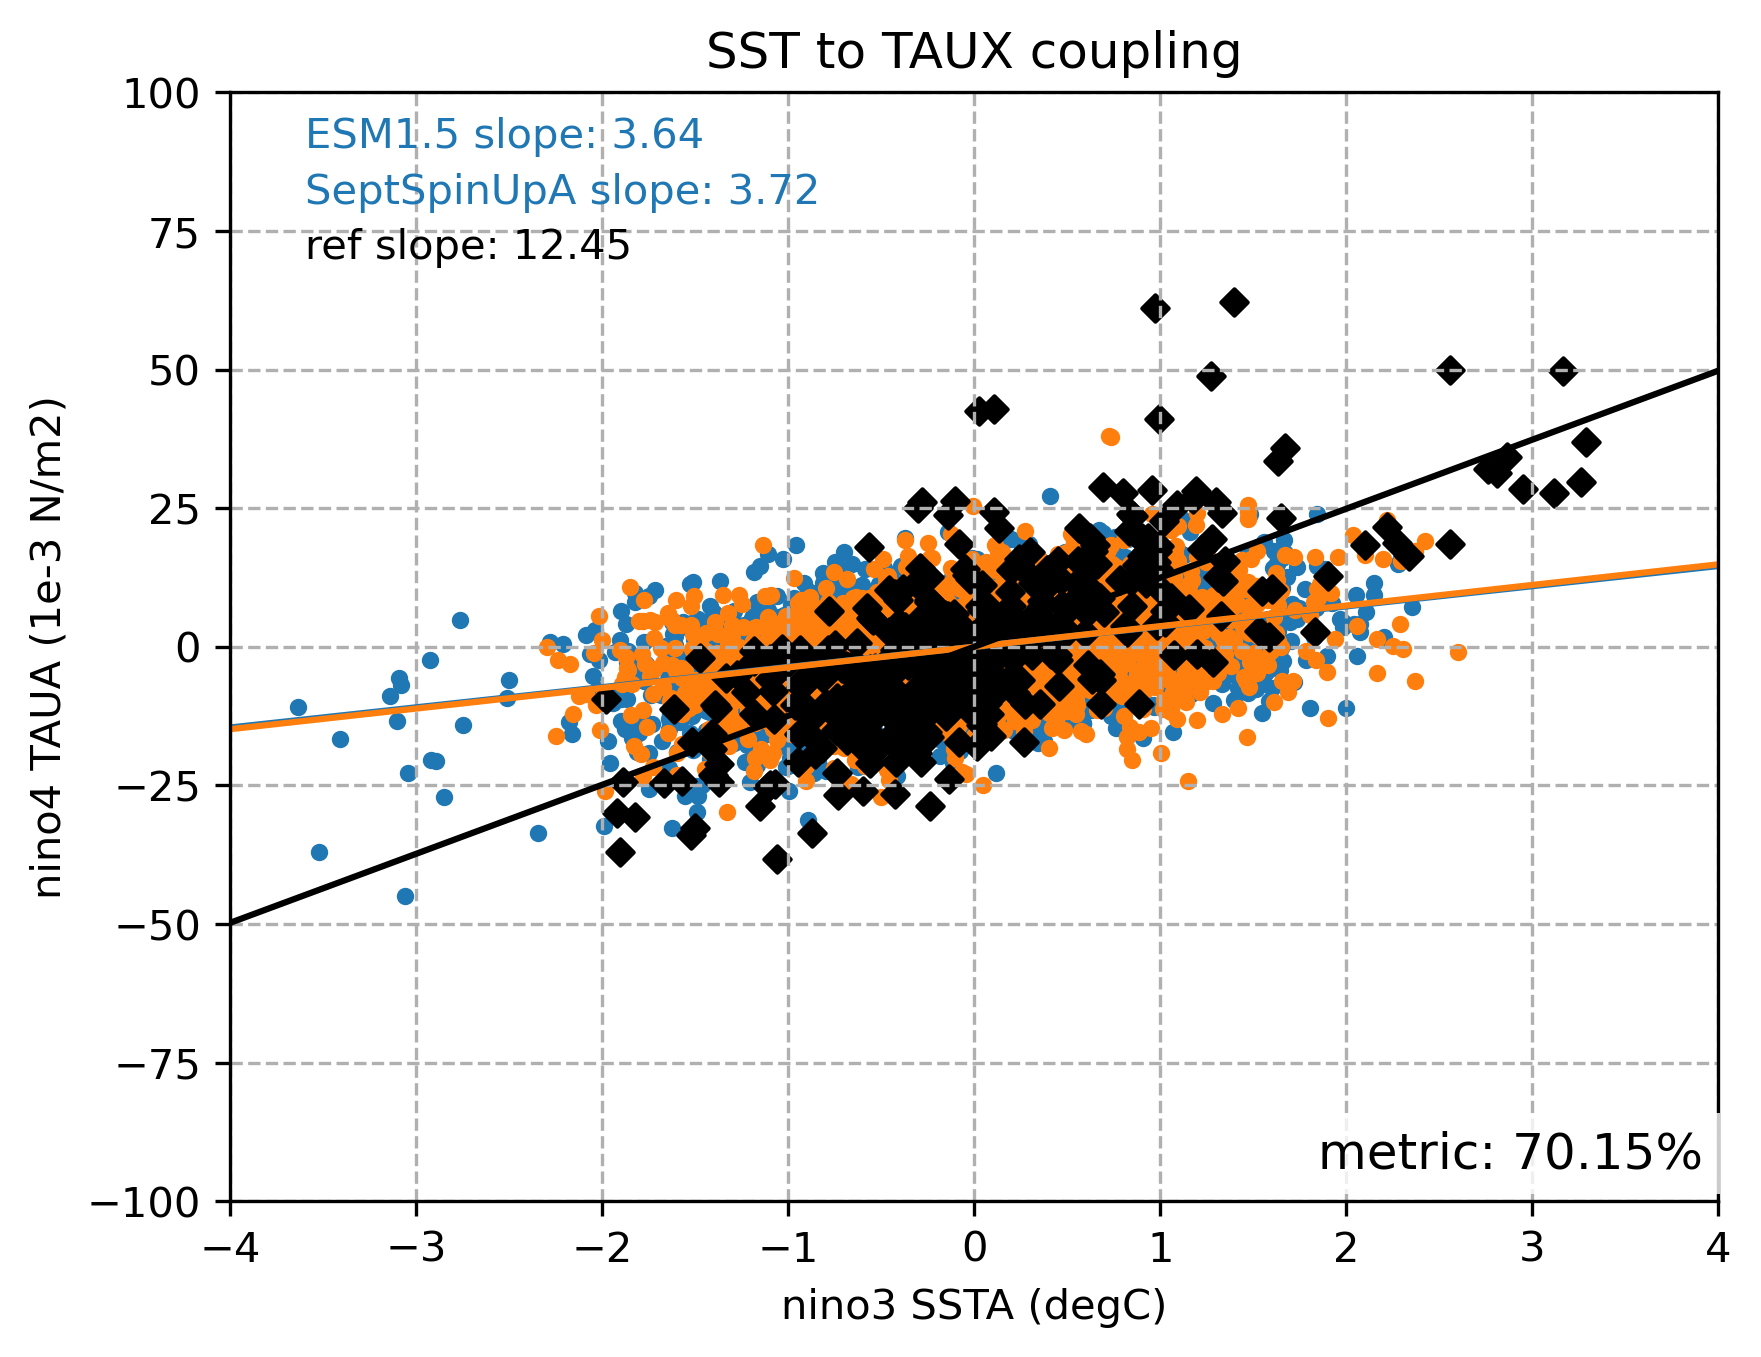

In [15]:
xseq = np.linspace(-4, 4, num=100)

# linregress(model_tauu_prep["ACCESS-ESM1-5"].data, model_tos_prep["ACCESS-ESM1-5"].data)
slope, intcpt = linreg_1d(model_ctrltauu_prep["ACCESS-ESM1-5"], model_ctrltos_prep["ACCESS-ESM1-5"])
plt.plot(xseq, intcpt+slope*xseq)
ctrlmod_slope = slope

slope, intcpt = linreg_1d(model_tauu_prep, model_tos_prep)
plt.plot(xseq, intcpt+slope*xseq)
mod_slope = slope

# # #problem with nan's in obs
# cube = obs_tauu_prep["NOAA-CIRES-20CR-V2"]

# cube_nan_fixed = cube.copy()

# # Lazy-safe NaN → 0 replacement
# cube_nan_fixed.data = cube_nan_fixed.lazy_data().map_blocks(
#     lambda x: np.nan_to_num(x, nan=0.0)
# )
# print(cube_nan_fixed.data)
# #obs_tauu_prep["NOAA-CIRES-20CR-V2"].data = cube_nan_fixed.data
# 

slope, intcpt = linreg_1d(obs_tauu_prep["NOAA-CIRES-20CR-V2"], obs_tos_prep["HadISST"])
plt.plot(xseq, intcpt+slope*xseq, color='black')
metric_val = abs((mod_slope-slope)/slope)*100

print(model_ctrltauu_prep["ACCESS-ESM1-5"].shape, model_ctrltos_prep["ACCESS-ESM1-5"].shape) #scatter plot
yunit = model_ctrltauu_prep["ACCESS-ESM1-5"].units 
xunit = model_ctrltos_prep["ACCESS-ESM1-5"].units
plt.scatter(model_ctrltos_prep["ACCESS-ESM1-5"].data, model_ctrltauu_prep["ACCESS-ESM1-5"].data, s=10)


print(model_tauu_prep.shape, model_tos_prep.shape) #scatter plot
yunit = model_tauu_prep.units 
xunit = model_tos_prep.units
plt.scatter(model_tos_prep.data, model_tauu_prep.data, s=10)


print(obs_tos_prep["HadISST"].shape, obs_tauu_prep["NOAA-CIRES-20CR-V2"].shape)
plt.scatter(obs_tos_prep["HadISST"].data, obs_tauu_prep["NOAA-CIRES-20CR-V2"].data,s=20, c='black', marker='D')
plt.xlim(-4,4)
plt.ylim(-100,100)

plt.title('SST to TAUX coupling')
plt.ylabel(f'nino4 TAUA ({yunit})')
plt.xlabel(f'nino3 SSTA ({xunit})')
plt.grid(linestyle='--')
## text slope
plt.text(0.05,0.95, f'ESM1.5 slope: {ctrlmod_slope:.2f}', color='C0',transform=plt.gca().transAxes)

plt.text(0.05,0.9, mylabel+f' slope: {mod_slope:.2f}', color='C0',transform=plt.gca().transAxes)
plt.text(0.05,0.85, f'ref slope: {slope:.2f}', color='black',transform=plt.gca().transAxes)

plt.text(0.99, 0.03, f'metric: {metric_val:.2f}%', fontsize=12, ha='right',
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
print(f'metric:{metric_val}')

Figure 1: scatterplot of sea surface temperature anomalies (SSTA) in the eastern equatorial Pacific (Niño3 averaged) and zonal wind stress anomalies (TauxA) in the western equatorial Pacific (Niño4 averaged), showing the strength of the SST-to-Taux coupling (usually too weak). The black and blue markers show respectively the reference and the model. The metric is based on the slope of the regression and is the absolute value of the relative difference: abs((model-ref)/ref)*100.



# Diagnostic Level 2

In [16]:
import pandas as pd

def linreg_df(ts, tauu):
    B_data = np.array(ts)
    B_with_intercept = np.vstack([B_data, np.ones_like(B_data)]).T
    coefs, _, _, _ = np.linalg.lstsq(B_with_intercept, np.array(tauu), rcond=None)
    slope, intercept = coefs[0], coefs[1]
    return slope, intercept

def plt_lvl2_subplot(ts_cube, tauu_cube, dataset_label):
    
    df = pd.DataFrame({'tos':ts_cube.data, 'tauu':tauu_cube.data})
    slopes = []
    print(dataset_label, 'shape: ', df.shape)
    plt.scatter(ts_cube.data, tauu_cube.data, c='k', s=10)
    xseq = np.linspace(-50, 50, num=50)
    slope, intcpt = linreg_df(df['tos'], df['tauu'])
    plt.plot(xseq, intcpt+slope*xseq, c='black')
    slopes.append(slope)
    
    xseq = np.linspace(-50, 0, num=50) #
    slope, intcpt = linreg_df(df.loc[df['tos']<0, 'tos'], df.loc[df['tos']<0, 'tauu'])
    
    plt.plot(xseq, intcpt+slope*xseq, linewidth=3)
    slopes.append(slope)
    
    xseq = np.linspace(0, 50, num=50)
    slope, intcpt = linreg_df(df.loc[df['tos']>0, 'tos'], df.loc[df['tos']>0, 'tauu'])
    plt.plot(xseq, intcpt+slope*xseq, color='red', linewidth=3)
    slopes.append(slope)

    plt.title(dataset_label)
    plt_settings(slopes)

def plt_settings(slopes):
    plt.xlim(-4,4)
    plt.xticks(np.arange(-4,5,2))
    plt.ylim(-100,100)
    plt.yticks(np.arange(-100,120,50))
    plt.grid(linestyle='--')
    plt.ylabel(f'nino4 TAUXA (1e-3 N/m2)')
    plt.xlabel(f'nino3 SSTA (°C)') #
    print(slopes)
    plt.text(0.02, 0.85, f'slope(all): {slopes[0]:.2f}\nslope(x<0): {slopes[1]:.2f}\nslope(x>0): {slopes[2]:.2f}', fontsize=12, ha='left',
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

HadISST_NOAA-CIRES-20CR-V2 shape:  (408, 2)
[12.447541, 12.499546, 11.57754]
ACCESS-ESM1-5 shape:  (2397, 2)
[3.640268, 5.192136, 2.8508031]
SeptSpinUpA shape:  (2172, 2)
[3.716047, 3.7445672, 2.9743283]


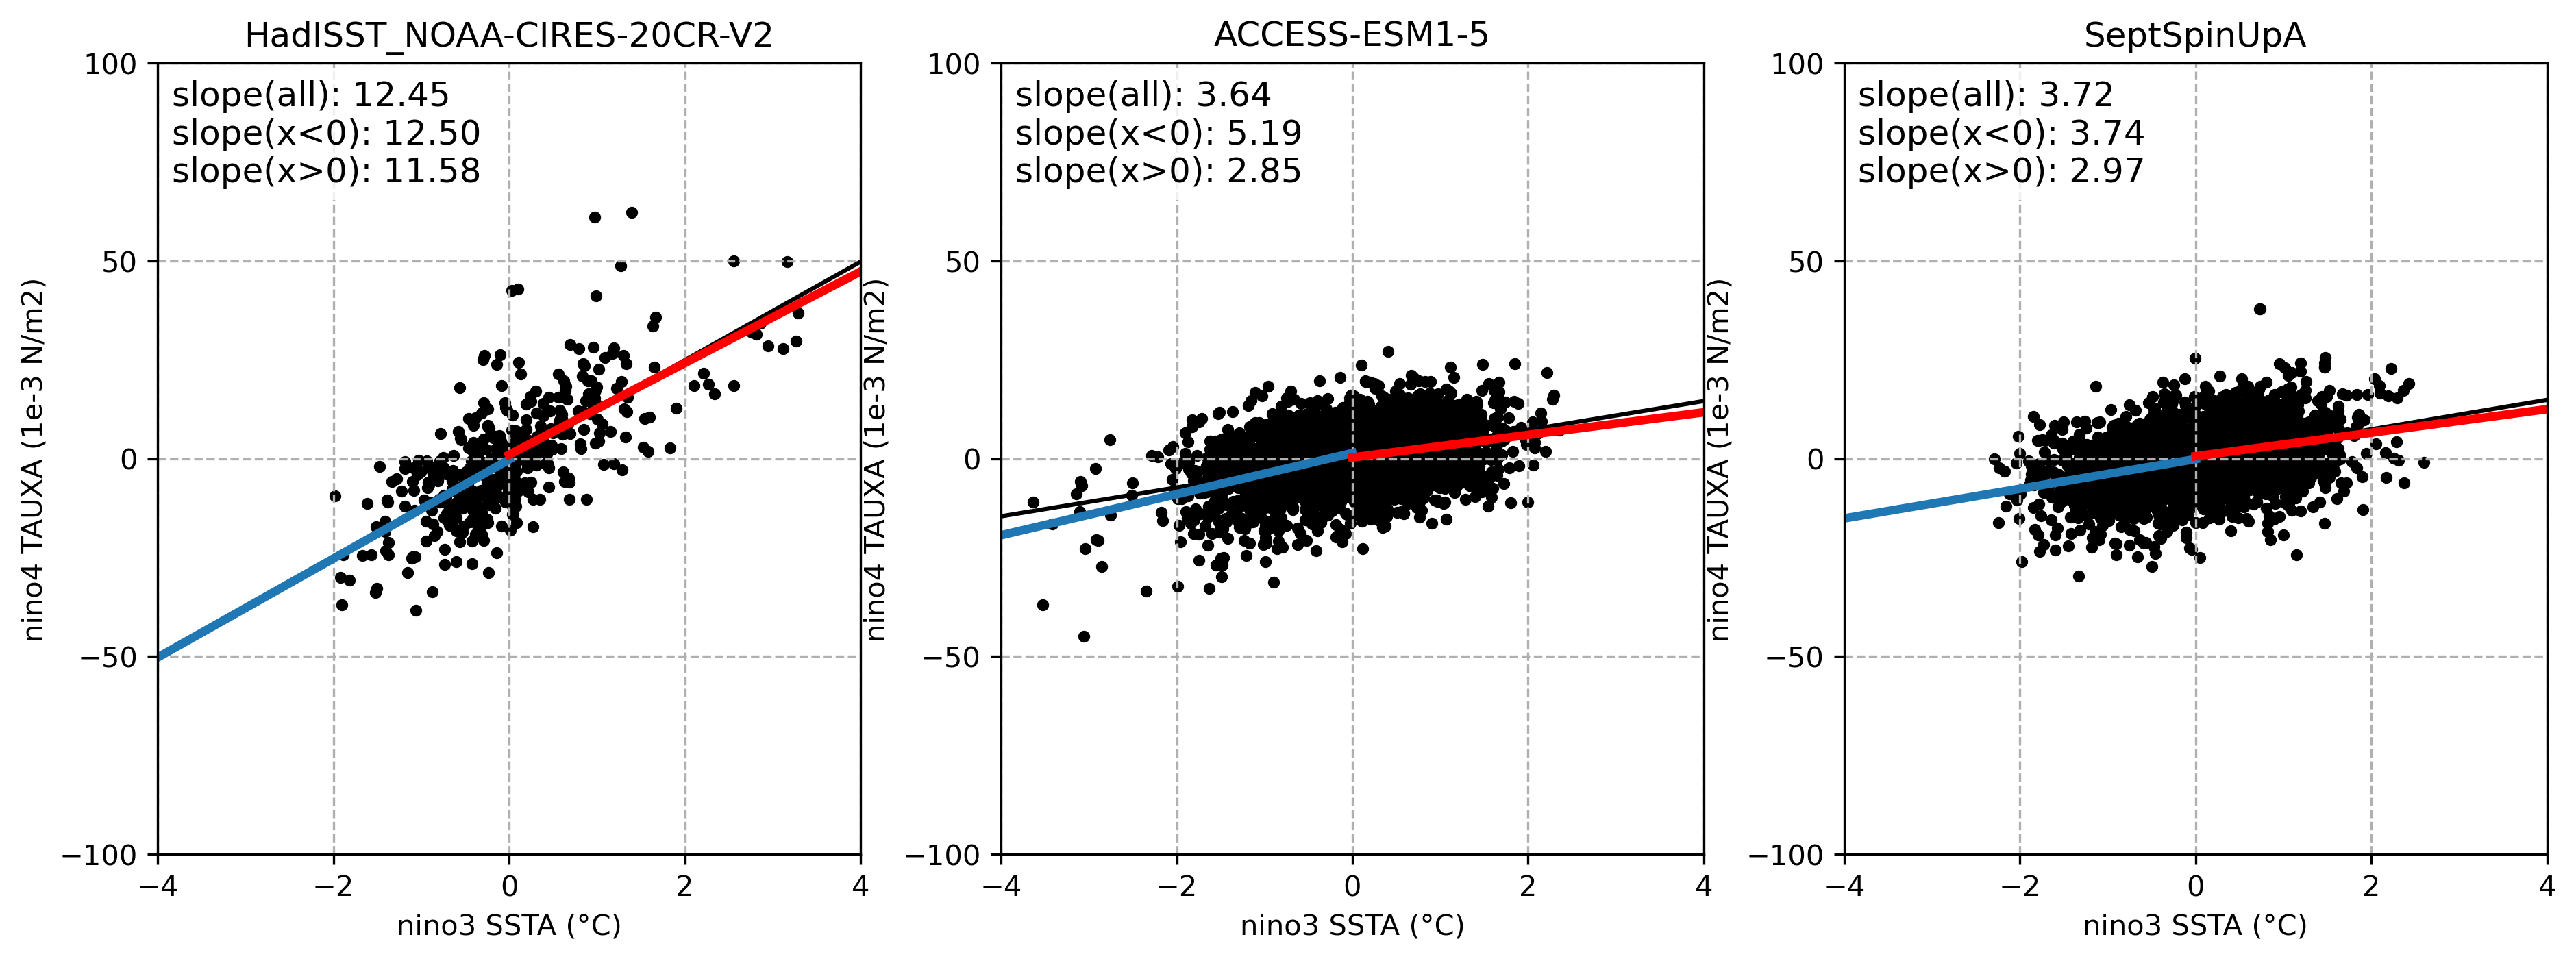

In [17]:
## plot figures
fig = plt.figure(figsize=(15, 5))
ax = plt.subplot(131)
plt_lvl2_subplot(obs_tos_prep["HadISST"], obs_tauu_prep["NOAA-CIRES-20CR-V2"], 'HadISST_NOAA-CIRES-20CR-V2')

ax = plt.subplot(132)
plt_lvl2_subplot(model_ctrltos_prep["ACCESS-ESM1-5"], model_ctrltauu_prep["ACCESS-ESM1-5"], 'ACCESS-ESM1-5')

ax = plt.subplot(133)

plt_lvl2_subplot(model_tos_prep, model_tauu_prep, mylabel)




Figure 2: scatterplot of sea surface temperature anomalies (SSTA) in the eastern equatorial Pacific (Niño3 averaged) and zonal wind stress anomalies (TauxA) in the western equatorial Pacific (Niño4 averaged), showing the possible nonlinearity in the strength of the SST-to-Taux coupling (usually shows no nonlinearity in both reference and model). The black, red and blue lines and numbers show respectively linear regression computed for all SSTA, SSTA>0 and SSTA<0, the left and right scatterplots show respectively the reference and the model.



## Dive down level 3
The third level shows the remote coupling in the equatorial Pacific.

In [18]:
#level 3 zonal runningaverage
from esmvalcore.preprocessor import meridional_statistics
from esmvalcore.preprocessor import mask_above_threshold, mask_below_threshold

def sst_east_3(cube,start,end):
    nino3_region = {"start_longitude": 210., "end_longitude": 270., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=start, end_year=end, start_month=1, end_month=12, start_day=1, end_day=31)
    cube = convert_units(cube, units="degC")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = mask_landsea(cube, mask_out="land")
    cube = anomalies(cube, period="monthly")
    cube = detrend(cube, dimension="time", method="linear")
    cube = extract_region(cube, **nino3_region)
    cube = area_statistics(cube,operator='mean')    
    return cube

def taux_eqp(cube,start,end):
    region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=start, end_year=end, start_month=1, end_month=12, start_day=1, end_day=31)

#    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = convert_units(cube, units="1e-3 N/m2")
#    cube = mask_landsea(cube, mask_out="land") 
    cube = anomalies(cube, period="monthly")
    cube = detrend(cube, dimension="time", method="linear")
    cube = extract_region(cube, **region)
    cube = meridional_statistics(cube,operator='mean')
    cube = rolling_window_statistics(cube, coordinate='longitude',operator='mean',window_length=30)
    return cube 


In [28]:
model_ctrltos_prep = {name: sst_east_3(dataset,900,1100) for name, dataset in model_ctrlts_datasets.items()}
model_ctrltauu_prep = {name: taux_eqp(dataset,900,1100) for name, dataset in model_ctrltauu_datasets.items()}

model_tos_prep = sst_east_3(esm16cube_ts,startyear,endyear) #for name, dataset in model_ts_datasets.items()}
model_tauu_prep = taux_eqp(esm16cube_tauu,startyear,endyear) #for name, dataset in model_tauu.items()}
model_tauu_prep_swap = model_tauu_prep.transpose([1,0])

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/cube.py:4343: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/cube.py:4898: IrisIgnoringBoundsWarning: The bounds of coordinate 'longitude' were ignored in the rolling window operation.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/cube.py:4343: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/cube.py:4898: IrisIgnoringBoundsWarning: The bounds of coordinate 'longitude' were ignored in the rolling window operation.
  warnings.warn(


In [29]:
print("sst time length:", model_ctrltos_prep['ACCESS-ESM1-5'].shape)
print("tauu time length:", model_ctrltauu_prep['ACCESS-ESM1-5'].shape)


print("sst time length:", model_tos_prep.shape)
print("tauu time length:", model_tauu_prep.shape)

sst time length: (2397,)
tauu time length: (2397, 35)
sst time length: (2172,)
tauu time length: (2172, 35)


In [20]:
obs_tos_prep = {name: sst_east_3(dataset,1979,2012) for name, dataset in obs_tos_datasets.items()}
obs_tauu_prep = {name: taux_eqp(dataset,1979,2012) for name, dataset in obs_tauu_datasets.items()}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/cube.py:4343: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/cube.py:4898: IrisIgnoringBoundsWarning: The bounds of coordinate 'longitude' were ignored in the rolling window operation.
  warnings.warn(


In [38]:
def lin_regress_matrix(cubeA, cubeBsst):
    
    A_data = cubeA.data.reshape(cubeA.shape[0], -1)  # Shape (time, spatial_points)
    if cubeA.shape[0] == cubeBsst.shape[0]:
        B_data = cubeBsst.data.flatten() # or all
    else:
        B_data = cubeBsst.data.compressed() # masked threshold cube (time,) 

    # Add intercept term by stacking a column of ones with cubeB
    B_with_intercept = np.vstack([B_data, np.ones_like(B_data)]).T
    
    print('least squares data shapes ',B_with_intercept.shape, A_data.shape)
    # Solve the linear equations using least squares method
    coefs, _, _, _ = np.linalg.lstsq(B_with_intercept, A_data, rcond=None)

    # Create a new Iris Cube for the regression results
    result_cube = iris.cube.Cube(coefs[0], long_name='regression SSTA,TAUXA',
                                 dim_coords_and_dims=[(cubeA.coord('longitude'), 0)])

    return result_cube




def feedback_nonlin(sst_cube, tauu_cube):
    tauu_aux = tauu_cube.copy()
    sst_coord = iris.coords.AuxCoord(sst_cube.data, sst_cube.standard_name, sst_cube.long_name, sst_cube.var_name, sst_cube.units)
    tauu_aux.add_aux_coord(sst_coord, 0)

    below0 = iris.Constraint(coord_values={sst_cube.standard_name:lambda cell: cell < 0})
    above0 = iris.Constraint(coord_values={sst_cube.standard_name:lambda cell: cell > 0})
    ssta_neg = mask_above_threshold(sst_cube.copy(), 0) #x<0
    ssta_pos = mask_below_threshold(sst_cube.copy(), 0) #x>0
    xbelow0 = tauu_aux.extract(below0)
    xabove0 = tauu_aux.extract(above0)

    outreg_cube = lin_regress_matrix(xbelow0, ssta_neg)
    posreg_cube = lin_regress_matrix(xabove0, ssta_pos)


    return outreg_cube, posreg_cube

least squares data shapes  (230, 2) (230, 36)
least squares data shapes  (178, 2) (178, 36)
least squares data shapes  (1114, 2) (1114, 35)
least squares data shapes  (1283, 2) (1283, 35)
least squares data shapes  (1086, 2) (1086, 35)
least squares data shapes  (1086, 2) (1086, 35)
least squares data shapes  (408, 2) (408, 36)
least squares data shapes  (2397, 2) (2397, 35)
least squares data shapes  (2172, 2) (2172, 35)


Text(0.5, 1.0, 'Wind stress feedback')

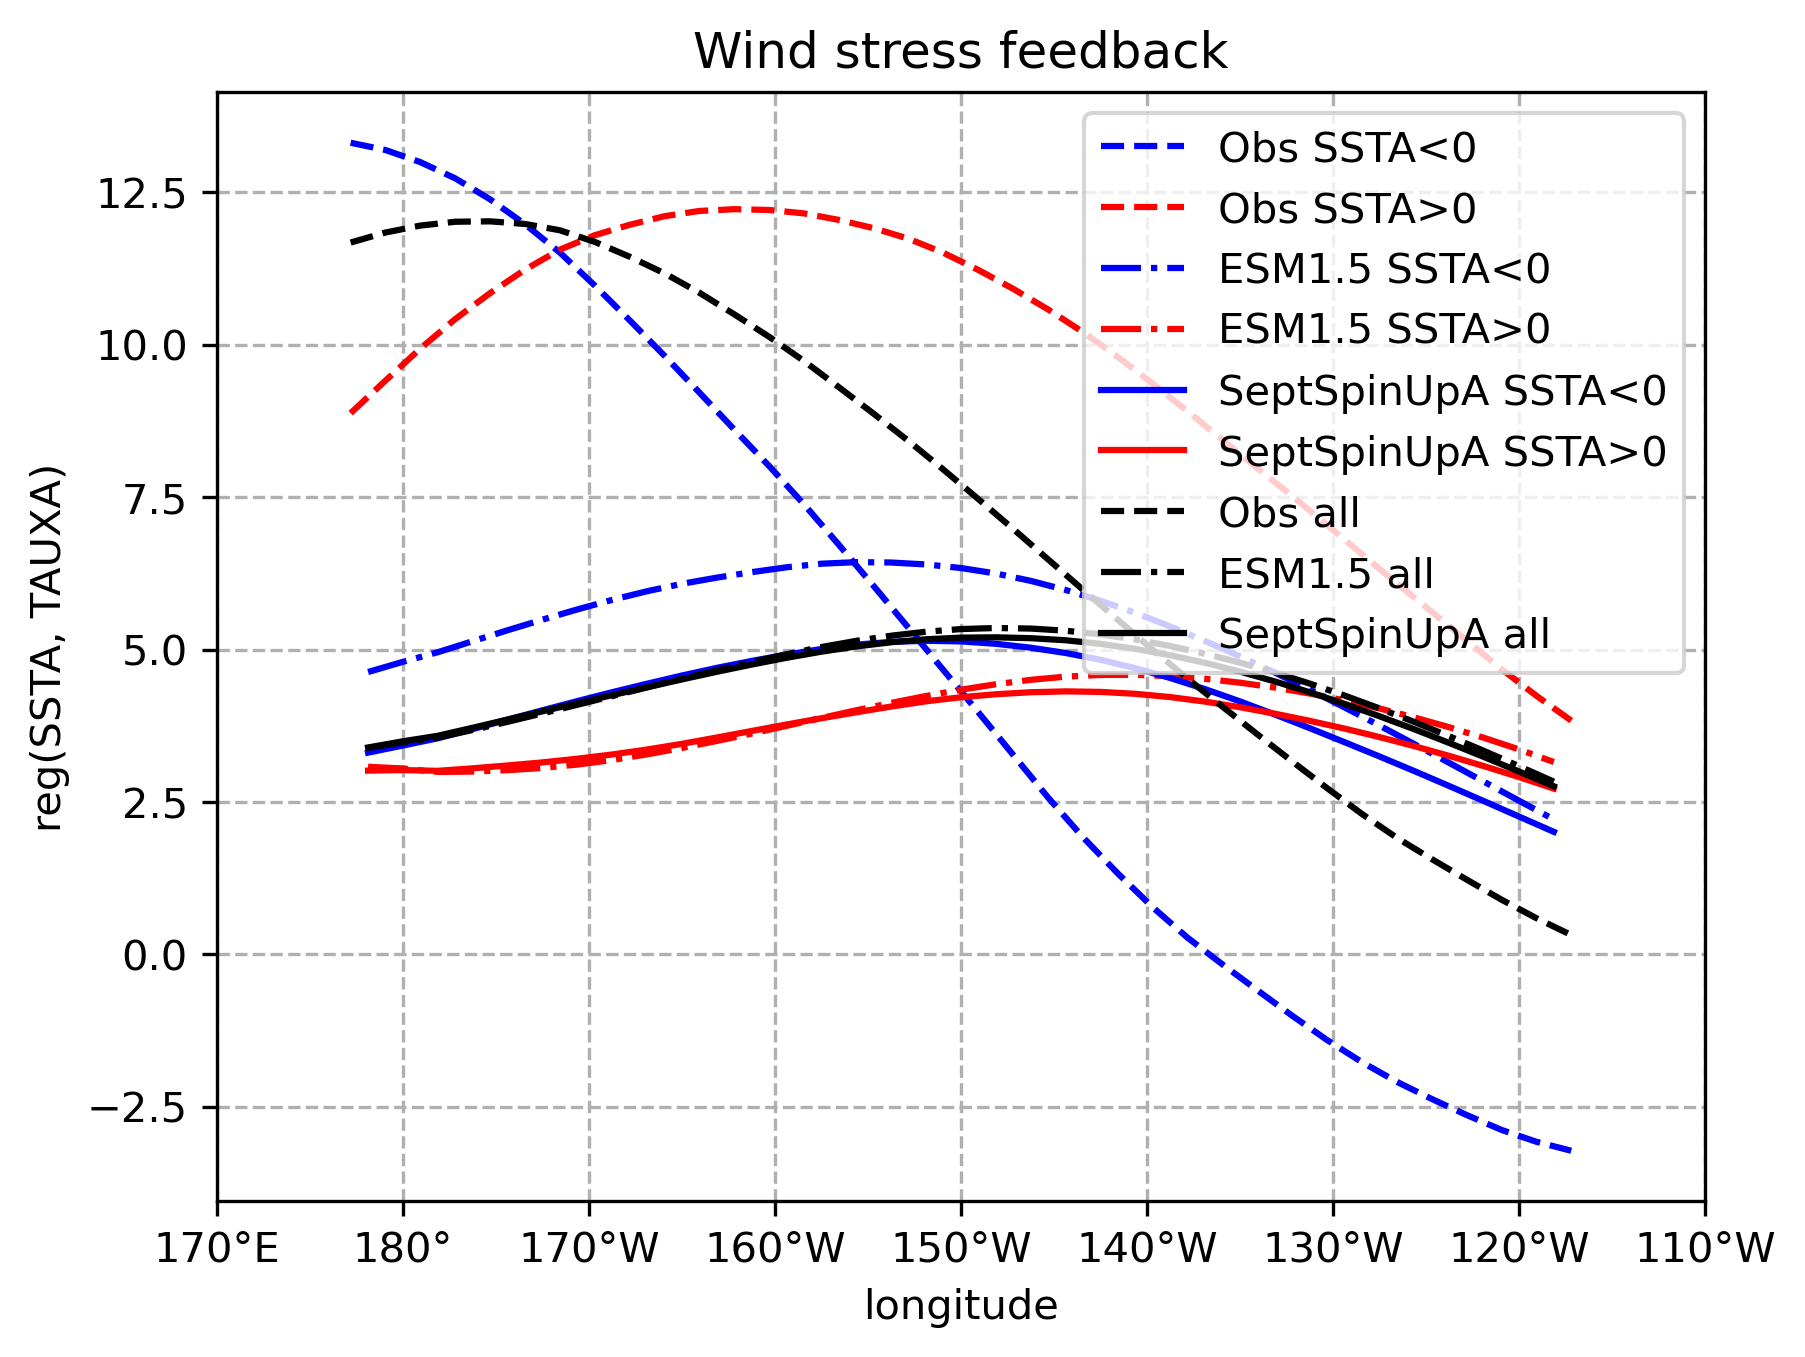

In [41]:
def format_longitude(x, pos):
    if x > 180:
        return f'{int(360 - x)}°W'
    elif x == 180:
        return f'{int(x)}°'
    else:
        return f'{int(x)}°E'


neg, pos = feedback_nonlin(obs_tos_prep["HadISST"], obs_tauu_prep["NOAA-CIRES-20CR-V2"])
qplt.plot(neg, color='blue', linestyle='--',label='Obs SSTA<0')
qplt.plot(pos, color='red', linestyle='--',label='Obs SSTA>0')

neg, pos = feedback_nonlin(model_ctrltos_prep["ACCESS-ESM1-5"], model_ctrltauu_prep["ACCESS-ESM1-5"])

qplt.plot(neg, color='blue', linestyle='-.', label='ESM1.5 SSTA<0')
qplt.plot(pos, color='red', linestyle='-.', label='ESM1.5 SSTA>0')

neg, pos = feedback_nonlin(model_tos_prep, model_tauu_prep)

qplt.plot(neg, color='blue', linestyle='solid', label=mylabel+' SSTA<0')
qplt.plot(pos, color='red', linestyle='solid', label=mylabel+' SSTA>0')

cb2 = lin_regress_matrix(obs_tauu_prep["NOAA-CIRES-20CR-V2"], obs_tos_prep["HadISST"])
qplt.plot(cb2, color='black', linestyle='--', label='Obs all')

cb = lin_regress_matrix(model_ctrltauu_prep["ACCESS-ESM1-5"],model_ctrltos_prep["ACCESS-ESM1-5"])
        
qplt.plot(cb, color='black', linestyle='-.', label='ESM1.5 all')


cb = lin_regress_matrix(model_tauu_prep,model_tos_prep)
        
qplt.plot(cb, color='black', linestyle='solid', label=mylabel+' all')

plt.xlim(170, 250) 
plt.xlabel('longitude')
plt.ylabel('reg(SSTA, TAUXA)')
plt.grid(linestyle='--')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_longitude))
plt.legend()
plt.title('Wind stress feedback')

Figure 3: spatial structure of zonal wind stress anomalies (TauxA) in the equatorial Pacific (meridional 5°S-5°N average; zonal 30° running average) regressed onto sea surface temperature anomalies (SSTA) in the eastern equatorial Pacific (Niño3 averaged), showing the possible nonlinearity in the strength of the SST-to-Taux coupling (the reference shows the maximum coupling around the dateline, west of the dateline for SSTA<0, east of the dateline for SSTA>0, but the amplitude of the maximum coupling is about the same; usually the models do not reproduce the displacement of the maximum coupling for all SSTA, SSTA<0, SSTA>0 and simulate a weakening of the coupling for SSTA<0). The black, red and blue lines and numbers show respectively linear regression computed for all SSTA, SSTA>0 and SSTA<0, the dashed and solid curves show respectively the reference and the model.

## Dive down level 4:

In [31]:
from esmvalcore.preprocessor import climate_statistics, extract_month
import iris.plot as iplt

def feedback_nonlin_lvl4(sst_cube, tauu_cube):
    tauu_aux = tauu_cube.copy()
    sst_coord = iris.coords.AuxCoord(sst_cube.data, sst_cube.standard_name, sst_cube.long_name, sst_cube.var_name, sst_cube.units)
    tauu_aux.add_aux_coord(sst_coord, 0)
    # print(sst_cube.standard_name, sst_cube.long_name, sst_cube.var_name, sst_cube.units)

    below0 = iris.Constraint(coord_values={sst_cube.standard_name:lambda cell: cell < 0})
    above0 = iris.Constraint(coord_values={sst_cube.standard_name:lambda cell: cell > 0})
    ssta_neg = mask_above_threshold(sst_cube.copy(), 0) #x<0
    ssta_pos = mask_below_threshold(sst_cube.copy(), 0) #x>0
    xbelow0 = tauu_aux.extract(below0)
    xabove0 = tauu_aux.extract(above0)
    
    outreg_cube = annual_structure_reg(xbelow0, ssta_neg)
    posreg_cube = annual_structure_reg(xabove0, ssta_pos)
    all_cube = annual_structure_reg(tauu_cube, sst_cube)

    return all_cube, posreg_cube, outreg_cube

def lin_regress_4(cubeA, cubeBsst):
    A_data = cubeA.data.reshape(cubeA.shape[0], -1)  # Shape (time, spatial_points)
    if cubeA.shape[0] == cubeBsst.shape[0]:
        B_data = cubeBsst.data.flatten() # or all
    else:
        B_data = cubeBsst.data.compressed() # compress masked

    B_with_intercept = np.vstack([B_data, np.ones_like(B_data)]).T

    coefs, _, _, _ = np.linalg.lstsq(B_with_intercept, A_data, rcond=None)
    return coefs[0]
    
def annual_structure_reg(nhf_cube, ts_cube):
    months_reg = []
    for i in range(1,13):
        #extract for both cubes
        nhf = extract_month(nhf_cube, month=i)
        ts = extract_month(ts_cube, month=i)
        coefs = lin_regress_4(nhf, ts)
        # collect array for months
        months_reg.append(coefs)

    # get month_number coordinate from an existing cube
    m_cube = climate_statistics(ts_cube, operator='max', period='month')
    
    #create cube, x = months, y = lon
    result_cube = iris.cube.Cube(np.array(months_reg), long_name='regression',
                                 dim_coords_and_dims=[(nhf.coord('longitude'), 1), (m_cube.coord('month_number'), 0)])
    return result_cube  

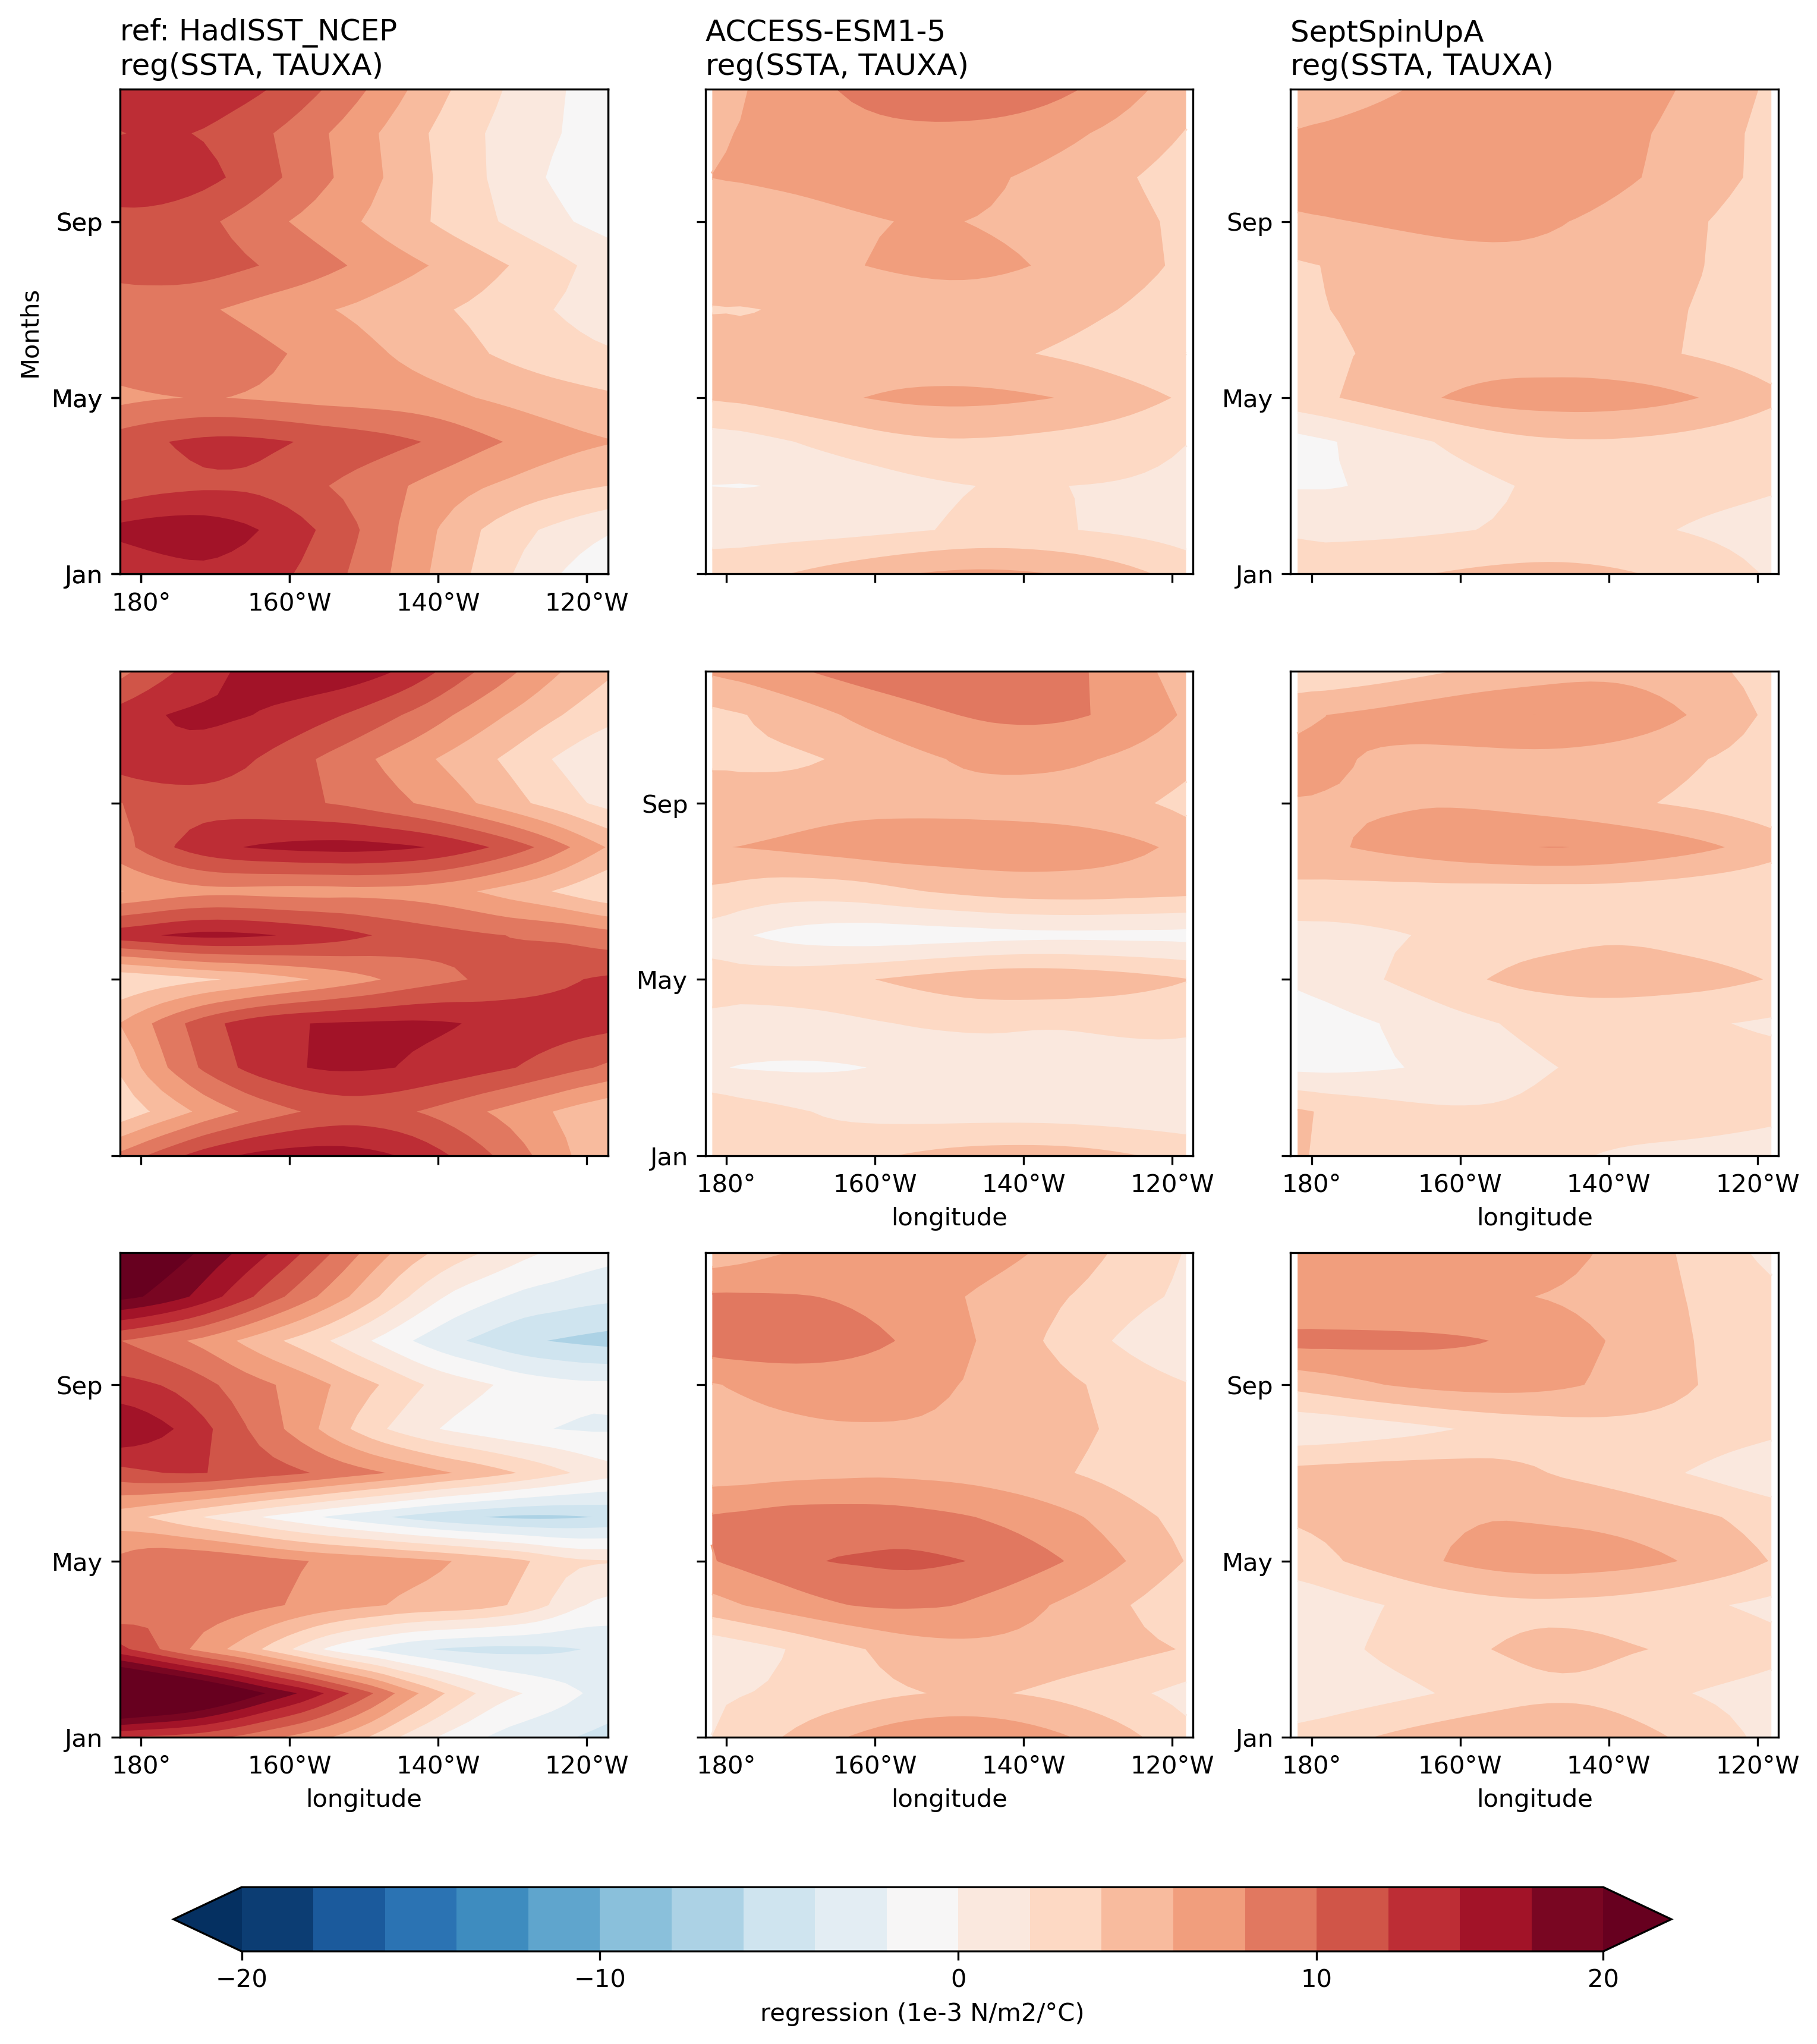

In [36]:
def format_longitude(x, pos):
    if x > 180:
        return f'{int(360 - x)}°W'
    elif x == 180:
        return f'{int(x)}°'
    else:
        return f'{int(x)}°E'

ctrlmodells = feedback_nonlin_lvl4(model_ctrltos_prep["ACCESS-ESM1-5"], model_ctrltauu_prep["ACCESS-ESM1-5"])
obsls = feedback_nonlin_lvl4(obs_tos_prep["HadISST"], obs_tauu_prep["NOAA-CIRES-20CR-V2"])
modells = feedback_nonlin_lvl4(model_tos_prep, model_tauu_prep)

sub = ['', '>0', '<0',] #all_cube, posreg_cube, outreg_cube

fig = plt.figure(figsize=(12, 12))
i = 331
ax1 = plt.subplot(i)

for isub, cbls in enumerate(zip(obsls, ctrlmodells,modells)):
    # build ls 

    for cb in cbls:
        if i == 331:
            ax1.set_yticks(range(1, 13, 4))
            ax1.set_yticklabels(['Jan', 'May', 'Sep'] )
            ax1.set_ylabel('Months')
            ax1.set_title('ref: HadISST_NCEP \nreg(SSTA, TAUXA)', loc='left')
        if i == 332:
            ax2 = plt.subplot(i, sharex=ax1, sharey=ax1)

            ax2.set_title(f'reg(SSTA{sub[isub]}, TAUXA)', loc='left')
            ax2.set_title('ACCESS-ESM1-5 \nreg(SSTA, TAUXA)', loc='left')
        else:

            ax2 = plt.subplot(i, sharex=ax1, sharey=ax1)
        if i==333:
            ax3 = plt.subplot(i, sharex=ax1, sharey=ax1)

            ax3.set_title(f'reg(SSTA{sub[isub]}, TAUXA)', loc='left')
            ax3.set_title(mylabel+' \nreg(SSTA, TAUXA)', loc='left')
        else:

            ax3 = plt.subplot(i, sharex=ax1, sharey=ax1)
        ## contour plt data
        cf1 = iplt.contourf(cb, coords=['longitude','month_number'], levels=np.arange(-20, 20, 2), extend='both', cmap="RdBu_r")
        
        if i < 335:
            plt.tick_params('x', labelbottom=False)
        else:
            plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_longitude)) #apply to bottom left =>325
            ax2.set_xlabel("longitude")
        
        if i%2 == 0:
            plt.tick_params(labelleft=False)
        
        i += 1


cax = plt.axes([0.15,0.01,0.7,0.03])
cbar = fig.colorbar(cf1, cax=cax, orientation='horizontal', extend='both', ticks=np.arange(-20, 21, 10))
cbar.set_label('regression (1e-3 N/m2/°C)')

Figure 4: spatio-mean annual structure of zonal wind stress anomalies (TauxA) in the equatorial Pacific (meridional 5°S-5°N average; zonal 30° running average) regressed onto sea surface temperature anomalies (SSTA) in the eastern equatorial Pacific (Niño3 averaged), showing the possible nonlinearity in the strength of the SST-to-Taux coupling (usually shows too weak, particularly during boreal autumn and winter coupling, the reference indicates that the coupling stops in boreal spring when SSTA<0 but not when SSTA>0, while the models usually simulate a stop of the coupling in both case). The first, second and third rows show respectively linear regression computed for all SSTA, SSTA>0 and SSTA<0, the left and right Hovmöllers show respectively the reference and the model.